# HistGradientBoosting Baseline & Optuna Tuning - PS-S06E08

This notebook implements a **HistGradientBoostingClassifier** model with Optuna hyperparameter tuning for **Playground Series – Season 6, Episode 8: Predicting Smartphone Addiction**.

We employ Stratified 5-Fold cross-validation, multi-seed training, and out-of-fold probability exporting to feed into the 4-Model Stacking Ensemble.

**Optuna Tuning Summary**:
- **Study DB**: `hgb_study.db`
- **Optimal Hyperparameters**: `max_depth=6`, `learning_rate=0.08`, `l2_regularization=1.0`
- **5-Seed OOF CV ROC AUC**: **0.963904**
- **Single-Model LB Score**: **0.96490**

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e08_experiment_setup import ExperimentSetup
from ps_s06e08_feature_engineering import FeatureFactory
from ps_s06e08_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

## 2. Configuration & Experiment Setup

In [2]:
MODEL_PREFIX = "hgb"
N_SPLITS = 5

setup = ExperimentSetup(
    model_name='HistGradientBoosting',
    use_gpu=False,
    perform_rfe=False,
    perform_optuna_tuning=True
)

seeds = setup.seed()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'addicted_label'

Warnings suppressed.


## 3. Data Loading & Feature Engineering

In [3]:
train_df = setup.read_dataset('training')
test_df = setup.read_dataset('test')

train_ids = train_df['id'].copy()
test_ids = test_df['id'].copy()

print(f"Raw Train shape: {train_df.shape}, Test shape: {test_df.shape}")

fe_strategies = [
    'encoding',
    'screen_time_ratios',
    'sleep_stress',
    'risk_score',
    'missing_flags',
    'quantile_binning',
]

factory = FeatureFactory(
    strategies=fe_strategies,
    impute_strategy='median_mode',
    target=TARGET,
    verbose=True
)

y = train_df[TARGET].copy()

X = factory.fit_transform(train_df)
X_test = factory.transform(test_df)

# Cast categorical features dynamically for HistGradientBoostingClassifier
cat_cols_detected = factory.get_cat_features(X)
for c in cat_cols_detected:
    if c in X.columns:
        X[c] = X[c].astype('category')
    if c in X_test.columns:
        X_test[c] = X_test[c].astype('category')

categorical_cols = X.select_dtypes(include=['category', 'object', 'bool']).columns.tolist()

print(f"Engineered Train shape: {X.shape}, Test shape: {X_test.shape}")
print(f"Dynamically detected categorical features ({len(categorical_cols)}): {categorical_cols}")

TRAINING DATASET

   id    age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0 24.000                      NaN               1.830         1.590   
1   1 19.000                    5.970               1.080           NaN   
2   2 18.000                    5.090                 NaN           NaN   
3   3 21.000                    6.420               1.260         1.420   
4   4 26.000                   11.200               1.870         2.810   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0             2.110        7.460                122.000             38.000   
1             3.030        8.220                 76.000             19.000   
2               NaN        6.250                134.000             60.000   
3             3.360        8.850                112.000             94.000   
4             1.950        5.250                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impa

## 4. SQLite-Backed Optuna Hyperparameter Tuning

Tunes `max_depth`, `learning_rate`, `l2_regularization`, and `max_bins` across 5-fold CV splits, persisting study results into `hgb_study.db`.

In [4]:
optuna_filename = 'optuna_params_hgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print("Running Optuna hyperparameter optimization for HistGradientBoosting v10 (fast convergence)...")
    
    pruner = optuna.pruners.NopPruner()
    
    study = optuna.create_study(
        study_name="hgb_study_optuna_v10",
        storage="sqlite:///hgb_study.db",
        load_if_exists=True,
        direction="maximize",
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=setup.seed()[0],
            n_startup_trials=5,
            multivariate=True
        )
    )
    
    # Enqueue previous best parameters if available
    if best_params and len(best_params) > 0:
        valid_params = {k: v for k, v in best_params.items() if k in ["max_depth", "learning_rate", "l2_regularization", "max_bins", "min_samples_leaf"]}
        study.enqueue_trial(valid_params)
        print("Enqueued previous best parameters into Optuna study.")
    
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.035, 0.12, log=True),
            'l2_regularization': trial.suggest_float('l2_regularization', 0.1, 20.0, log=True),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 40, 150),
            'max_bins': trial.suggest_int('max_bins', 180, 255),
            'max_iter': 1200,
            'early_stopping': True,
            'n_iter_no_change': 30,
            'categorical_features': categorical_cols,
            'random_state': setup.seed()[0]
        }
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=setup.seed()[0])
        oof_preds = np.zeros(len(y))
        
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
            X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
            X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
            
            clf = HistGradientBoostingClassifier(**params)
            clf.fit(X_tr, y_tr)
            oof_preds[val_idx] = clf.predict_proba(X_val)[:, 1]
            
        score = roc_auc_score(y, oof_preds)
        return score

    study.optimize(objective, n_trials=30, show_progress_bar=True, timeout=10800)

    best_params = study.best_params
    print(f"Best Trial CV ROC AUC: {study.best_value:.6f}")
    print("Best Hyperparameters:")
    print(json.dumps(study.best_params, indent=2))
    
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print("Using loaded parameters:", best_params)

Loaded 5 parameters from optuna_params_hgb.json
Running Optuna hyperparameter optimization for HistGradientBoosting v10 (fast convergence)...


[I 2026-08-29 14:52:41,313] A new study created in RDB with name: hgb_study_optuna_v10


Enqueued previous best parameters into Optuna study.


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-29 14:57:34,782] Trial 0 finished with value: 0.9631471846950281 and parameters: {'max_depth': 7, 'learning_rate': 0.09476687547041161, 'l2_regularization': 8.278157112698686, 'min_samples_leaf': 141, 'max_bins': 251}. Best is trial 0 with value: 0.9631471846950281.
[I 2026-08-29 15:03:04,835] Trial 1 finished with value: 0.9610693102748105 and parameters: {'max_depth': 6, 'learning_rate': 0.04630733090726499, 'l2_regularization': 12.61471581153221, 'min_samples_leaf': 123, 'max_bins': 203}. Best is trial 0 with value: 0.9631471846950281.
[I 2026-08-29 15:06:44,913] Trial 2 finished with value: 0.9619274372029705 and parameters: {'max_depth': 6, 'learning_rate': 0.11958840376181602, 'l2_regularization': 3.386273238441342, 'min_samples_leaf': 96, 'max_bins': 217}. Best is trial 0 with value: 0.9631471846950281.
[I 2026-08-29 15:11:30,858] Trial 3 finished with value: 0.9610308500308017 and parameters: {'max_depth': 5, 'learning_rate': 0.06620388161894918, 'l2_regularization':

...

Upload successful: optuna_params_catboost.json (246B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 282/282 [00:00<00:00, 527B/s]


Upload successful: optuna_params_xgb.json (282B)
Starting upload for file selected_features_xgb.json


100%|██████████| 1.11k/1.11k [00:00<00:00, 2.03kB/s]


Upload successful: selected_features_xgb.json (1KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e08-artifacts
Kaggle artifacts dataset upload completed successfully!


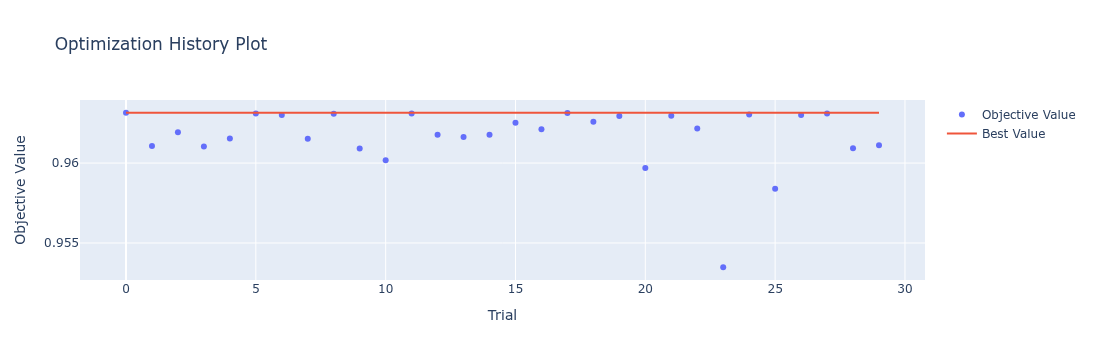

In [5]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

## 5. Multi-Seed 5-Fold Model Training

In [6]:
hgb_params = {
    'max_iter': 1500,
    'learning_rate': best_params.get('learning_rate', 0.05),
    'max_depth': best_params.get('max_depth', 5),
    'l2_regularization': best_params.get('l2_regularization', 1.0),
    'min_samples_leaf': best_params.get('min_samples_leaf', 70),
    'max_bins': best_params.get('max_bins', 240),
    'categorical_features': categorical_cols,
    'early_stopping': True,
    'n_iter_no_change': 30
}

seed_oof_preds = []
seed_test_preds = []
seed_scores = []
models = []
eval_results = []

for seed_idx, seed in enumerate(seeds):
    print(f"\n================ SEED RUN {seed_idx+1}/{len(seeds)}: seed={seed} ================")
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    oof_probs = np.zeros(len(train_df))
    test_probs = np.zeros(len(test_df))
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = HistGradientBoostingClassifier(
            **hgb_params, 
            random_state=seed + fold
        )
        model.fit(X_train, y_train)
        
        val_pred = model.predict_proba(X_val)[:, 1]
        oof_probs[val_idx] = val_pred
        test_probs += model.predict_proba(X_test)[:, 1] / N_SPLITS
        
        fold_auc = roc_auc_score(y_val, val_pred)
        print(f"  Fold {fold+1} ROC AUC: {fold_auc:.6f}")
        
        models.append(model)
        if hasattr(model, 'train_score_') and hasattr(model, 'validation_score_'):
            eval_results.append({
                'train': model.train_score_,
                'val': model.validation_score_
            })
        
    seed_auc = roc_auc_score(y, oof_probs)
    print(f"--- Seed {seed} CV ROC AUC: {seed_auc:.6f} ---")
    seed_oof_preds.append(oof_probs)
    seed_test_preds.append(test_probs)
    seed_scores.append(seed_auc)

final_oof_probs = np.mean(seed_oof_preds, axis=0)
final_test_probs = np.mean(seed_test_preds, axis=0)
final_cv_auc = roc_auc_score(y, final_oof_probs)

print("\n" + "="*60)
print(f"HistGradientBoosting Seed-Averaged CV ROC AUC: {final_cv_auc:.6f}")
print("="*60)


================ SEED RUN 1/5: seed=10301 ================
  Fold 1 ROC AUC: 0.962481
  Fold 2 ROC AUC: 0.963120
  Fold 3 ROC AUC: 0.963487
  Fold 4 ROC AUC: 0.963619
  Fold 5 ROC AUC: 0.963164
--- Seed 10301 CV ROC AUC: 0.963173 ---

================ SEED RUN 2/5: seed=42 ================
  Fold 1 ROC AUC: 0.962180
  Fold 2 ROC AUC: 0.962947
  Fold 3 ROC AUC: 0.963288
  Fold 4 ROC AUC: 0.964251
  Fold 5 ROC AUC: 0.962958
--- Seed 42 CV ROC AUC: 0.963124 ---

================ SEED RUN 3/5: seed=2026 ================
  Fold 1 ROC AUC: 0.962261
  Fold 2 ROC AUC: 0.964016
  Fold 3 ROC AUC: 0.963692
  Fold 4 ROC AUC: 0.963307
  Fold 5 ROC AUC: 0.962481
--- Seed 2026 CV ROC AUC: 0.963150 ---

================ SEED RUN 4/5: seed=777 ================
  Fold 1 ROC AUC: 0.963428
  Fold 2 ROC AUC: 0.963331
  Fold 3 ROC AUC: 0.963176
  Fold 4 ROC AUC: 0.963047
  Fold 5 ROC AUC: 0.962490
--- Seed 777 CV ROC AUC: 0.963092 ---

================ SEED RUN 5/5: seed=888 ================
  Fold 1 ROC A

## 6. Performance Visualization

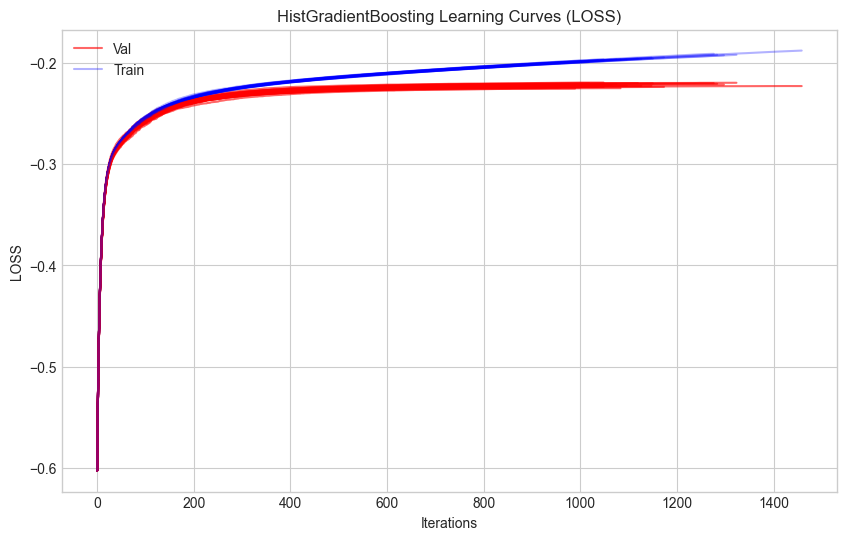

In [7]:
mviz = ModelVisualizer(model_name='HistGradientBoosting')

# Plot HistGradientBoosting loss learning curves
if eval_results:
    mviz.plot_learning_curves(eval_results, metric='loss')
elif models:
    mviz.plot_learning_curves(models, metric='loss')

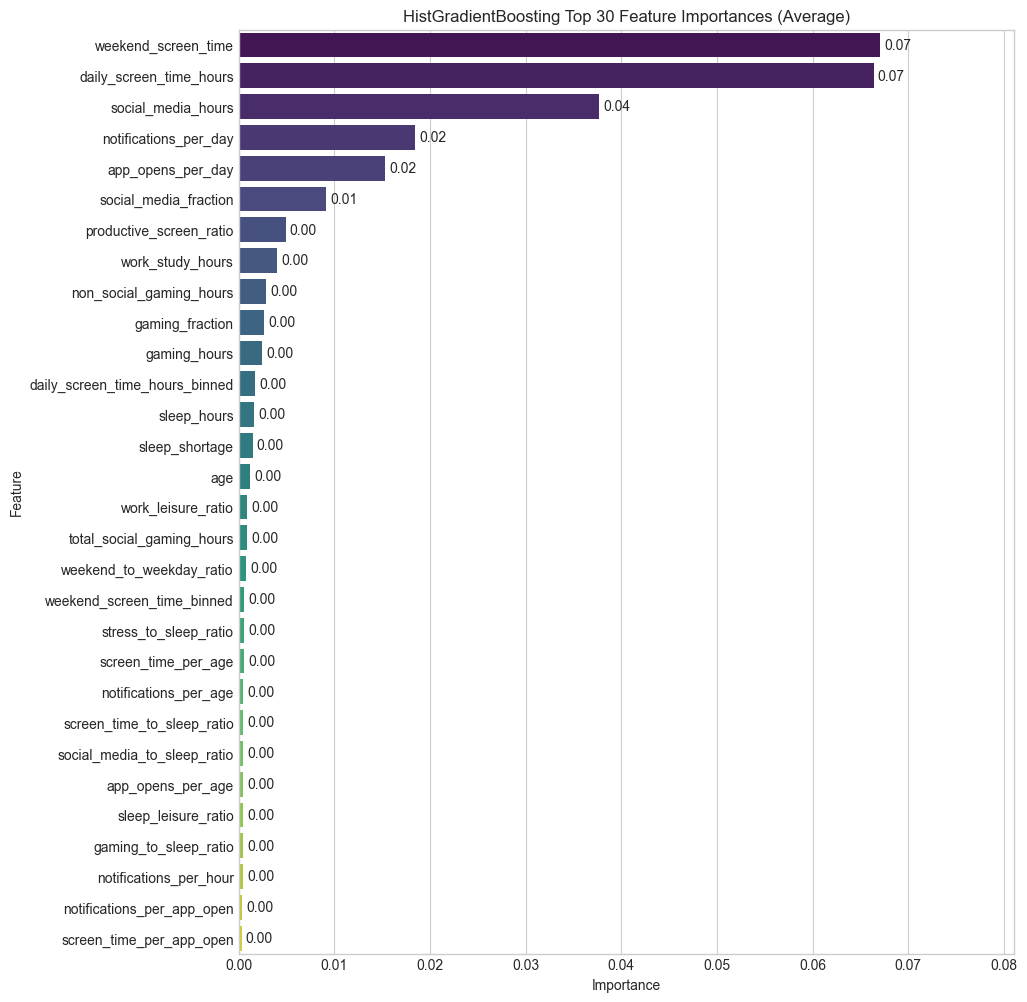

In [8]:
# Plot Feature Importances via Permutation Importance (passing validation data)
mviz.plot_feature_importance(models, X_val=X, y_val=y, top_n=30, show_values=True)

<Figure size 800x600 with 0 Axes>

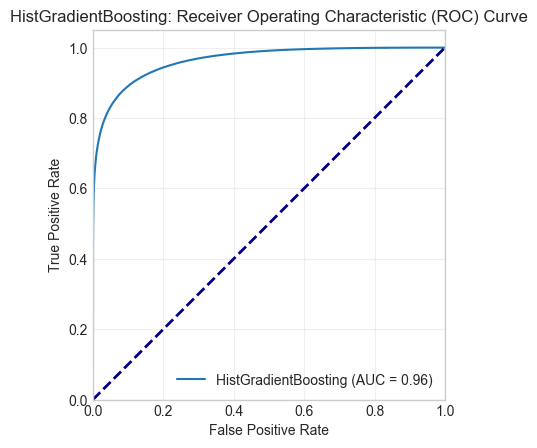

In [9]:
# Plot Out-Of-Fold ROC Curve
mviz.plot_roc_curve(y_true=y, y_score=final_oof_probs)

Confusion matrix, without normalization


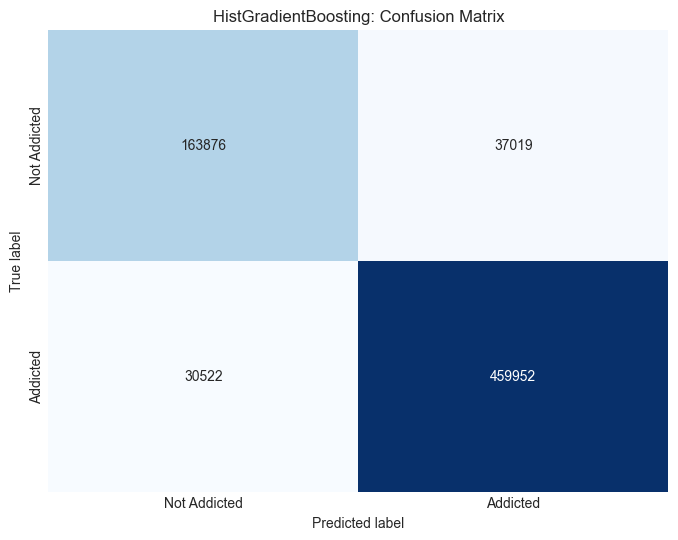

In [10]:
# Plot Confusion Matrix
y_pred_class = (final_oof_probs > 0.5).astype(int)
mviz.plot_confusion_matrix(
    y_true=y,
    y_pred=y_pred_class,
    classes=['Not Addicted', 'Addicted']
)

## 7. Submission & OOF Exporting

In [11]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': final_test_probs
})
submission_df.to_csv('submission.csv', index=False)
print("Saved submission.csv successfully!")

oof_probs_2d = np.column_stack([1 - final_oof_probs, final_oof_probs])
test_probs_2d = np.column_stack([1 - final_test_probs, final_test_probs])
filled_mask = np.ones(len(train_df), dtype=bool)

setup.save_probabilities(MODEL_PREFIX, oof_probs_2d, train_df['id'], y, filled_mask, test_probs_2d, test_df['id'])
print(f"Saved {MODEL_PREFIX} OOF and test probabilities for ensembling!")

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/hgb_oof_probs.csv
 - predictions/hgb_test_probs.csv
Saved hgb OOF and test probabilities for ensembling!
